# BaSSSh-seq — Bacterial scRNA-seq analysis
## Part 2: Leiden Clustering, Annotation & CellTypist

**Pipeline:**  
Load → UMAP/Leiden → Compositie → Markers → Annotatie → CellTypist → Trajectory

**Key parameters:**
- UMAP: `min_dist=0.24`, `spread=0.21`
- Leiden: `resolution=0.205` → 7 clusters
- Trajectory: Palantir, `n_components=5`, `num_waypoints=500`

## 6. Imports & settings
Same environment as Part 1. Run this cell first before anything else.

In [43]:
import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import celltypist

sc.settings.verbosity = 1
sc.settings.set_figure_params(dpi=100, frameon=False)

## 7. Load merged preprocessed data
Load the combined, HVG-filtered, BBKNN-corrected object produced at the end of Part 1.
Expected shape: **(7884 cells × 1015 HVGs)**. Cell names follow the `bf_X` / `p_X` convention.

In [44]:
adata_bacteria = sc.read_h5ad("/mnt/c/Users/natha/OneDrive/Bio-informatica_25-26/International Internship/Internship-25-26/CellTypist_pipeline/data/3_Merged_data/bacteria_all_genes_combined.h5ad")

# Sanity check
print(f"Cells : {adata_bacteria.n_obs}  (expected 7884)")
print(f"Genes : {adata_bacteria.n_vars} (expected 2853 HVGs)")
print(f"Columns in .obs : {adata_bacteria.obs.columns.tolist()}")
print(f"First 5 cell names: {adata_bacteria.obs_names[:5].tolist()}")
adata_bacteria.obs.head()

Cells : 7884  (expected 7884)
Genes : 2853 (expected 2853 HVGs)
Columns in .obs : ['total_counts', 'sample']
First 5 cell names: ['68', '96', '104', '107', '131']


,total_counts,sample
68,14.120000,bf
96,8.770000,bf
104,16.639999,bf
107,8.700000,bf
131,9.680000,bf


In [45]:
import scanpy as sc
import matplotlib.pyplot as plt

print("--- Starting Leiden Clustering & UMAP Pipeline ---")

# 1. Compute PCA (if not already present in the AnnData object)
if 'X_pca' not in adata_bacteria.obsm:
    print("Computing PCA coordinates...")
    sc.tl.pca(adata_bacteria, svd_solver='arpack')

# 2. Compute the neighborhood graph
print("Computing neighbors graph...")
sc.pp.neighbors(adata_bacteria, n_neighbors=15, n_pcs=30)

# 3. Run Leiden Clustering using your custom resolution
print("Running Leiden clustering (resolution=0.205)...")
sc.tl.leiden(adata_bacteria, resolution=0.205, key_added='leiden')

# 4. Compute UMAP coordinates using your custom min_dist and spread
print("Computing UMAP coordinates (min_dist=0.24, spread=0.21)...")
sc.tl.umap(adata_bacteria, min_dist=0.24, spread=0.21)

print("\nSUCCESS: Pipeline completed successfully!")
print("Your UMAP coordinates and Leiden clusters are now ready to be plotted.")

--- Starting Leiden Clustering & UMAP Pipeline ---
Computing PCA coordinates...
Computing neighbors graph...
Running Leiden clustering (resolution=0.205)...
Computing UMAP coordinates (min_dist=0.24, spread=0.21)...

SUCCESS: Pipeline completed successfully!
Your UMAP coordinates and Leiden clusters are now ready to be plotted.


Plotting UMAP 1: Biofilm vs Planktonic...


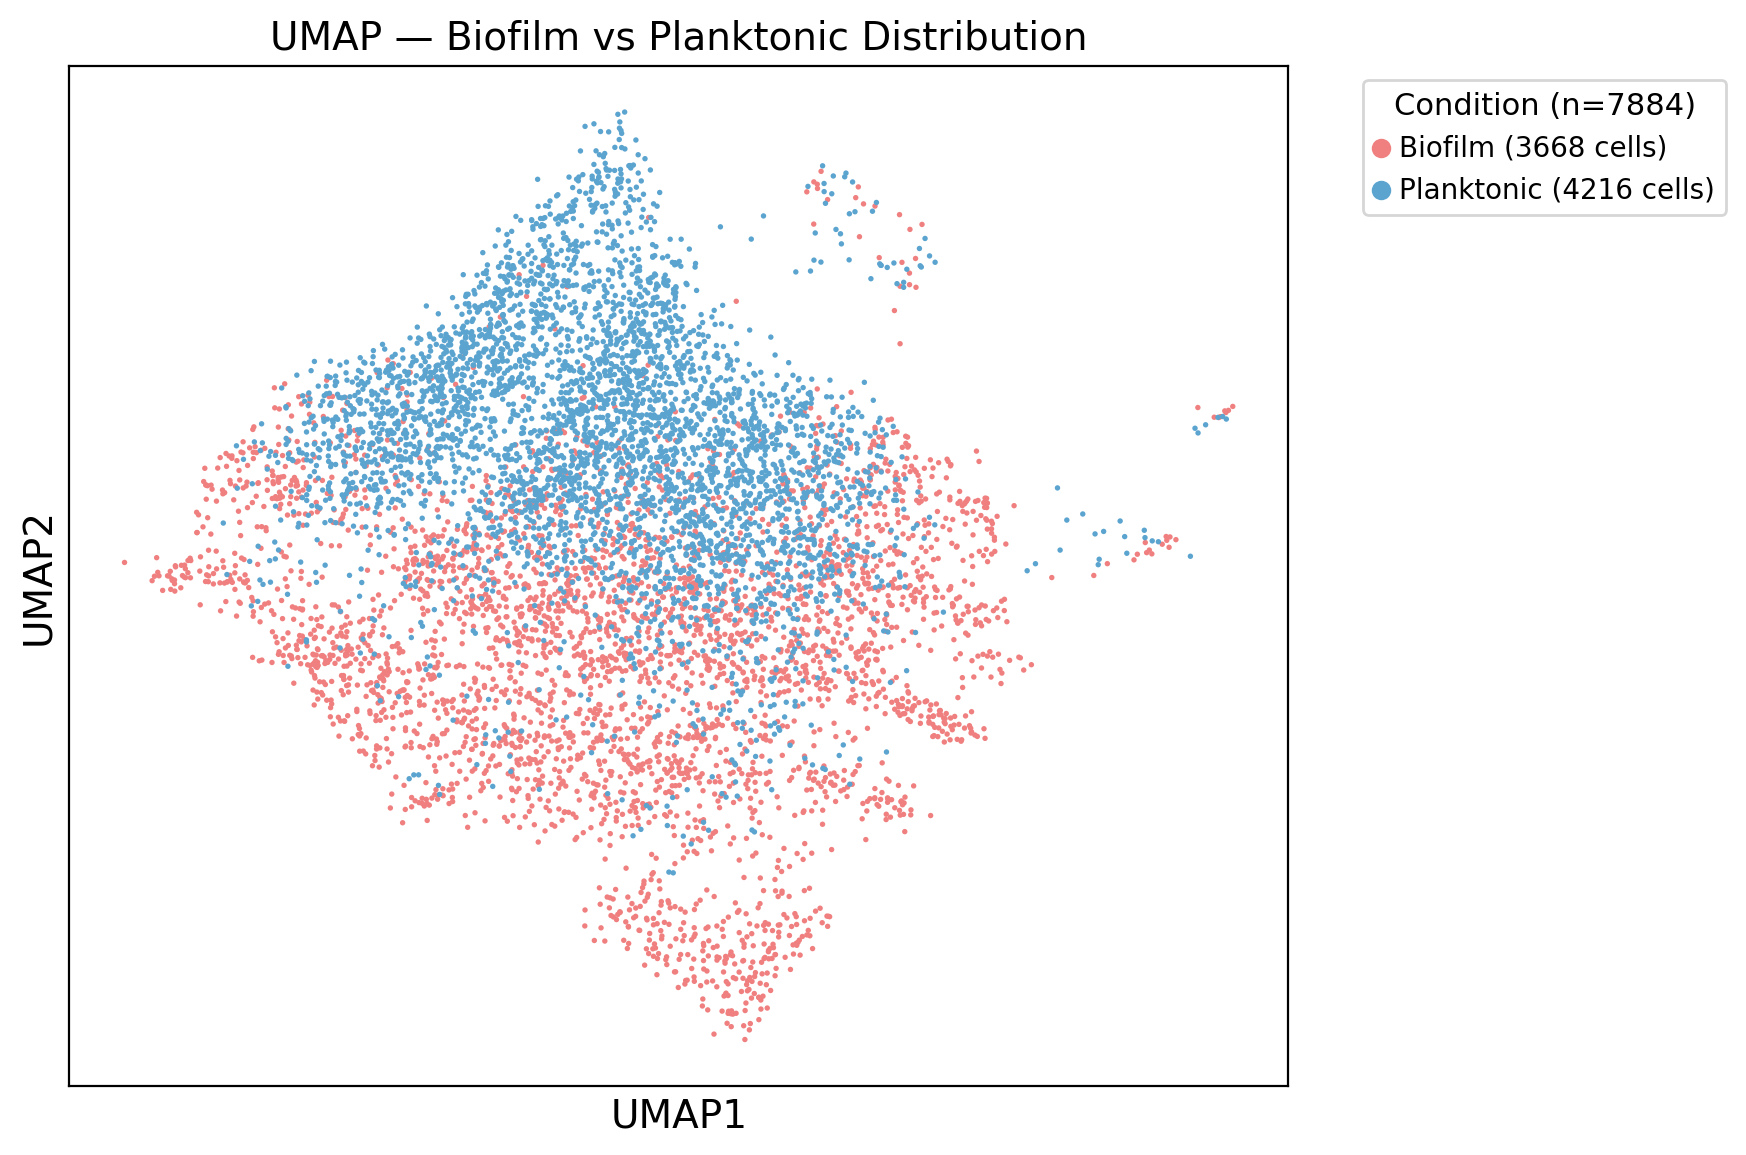

Saved successfully: UMAP_BF_vs_Planktonic.pdf

Plotting UMAP 2: Leiden Clusters...


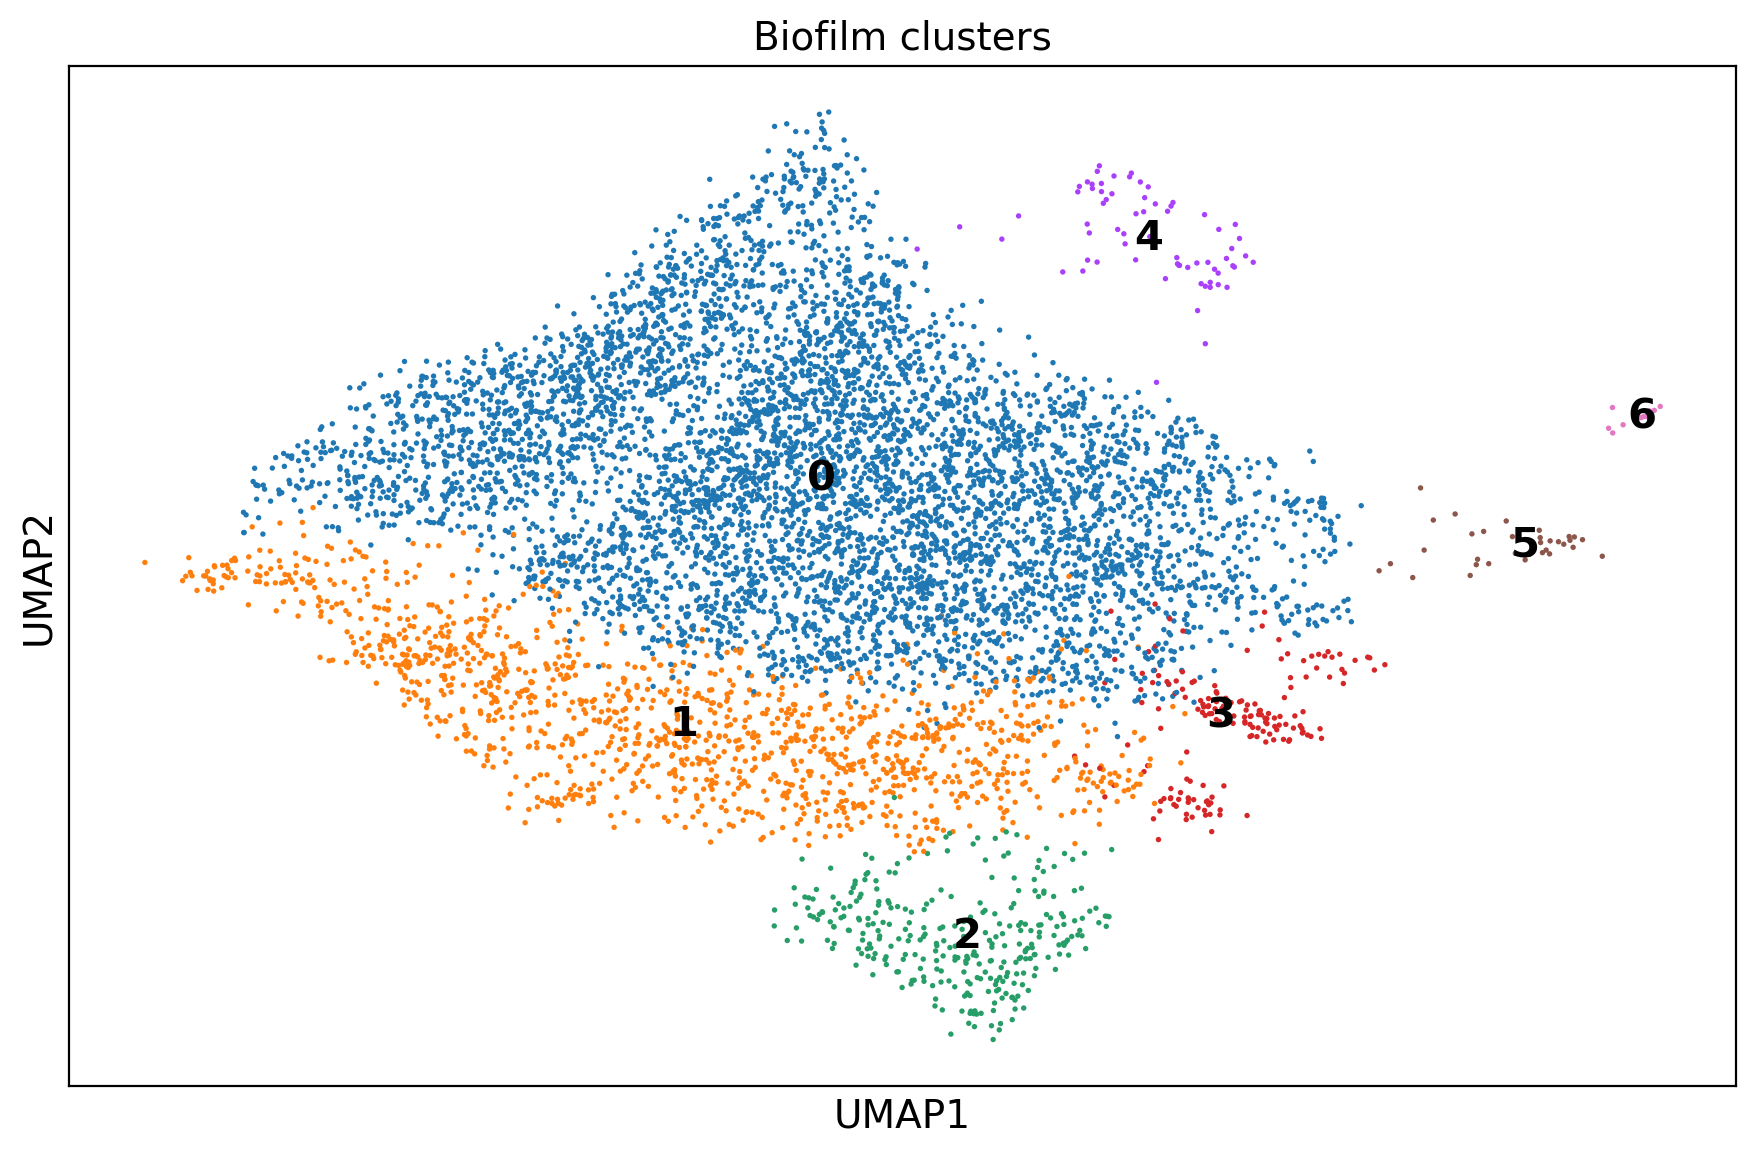

Saved successfully: UMAP_Leiden_Clusters.pdf

--- Both structural UMAPs generated cleanly! ---


In [46]:
import matplotlib.pyplot as plt
import scanpy as sc

# ─── PDF 1: Biofilm vs Planktonic Distribution ────────────────────────────────
print("Plotting UMAP 1: Biofilm vs Planktonic...")
fig, ax = plt.subplots(figsize=(9, 6))

# Updated palette mapping to match the actual data strings ('bf' instead of 'Biofilm')
sc.pl.umap(
    adata_bacteria,
    color='sample',  
    palette={'bf': '#F08080', 'p': '#5BA4CF'},  # Matches actual values in your .obs table
    title='UMAP — Biofilm vs Planktonic Distribution',
    legend_loc='right margin',
    frameon=True,
    ax=ax,
    show=False
)

# Calculate condition cell counts using your actual short data values
bf_count = (adata_bacteria.obs['sample'] == 'bf').sum()
p_count  = (adata_bacteria.obs['sample'] == 'p').sum()

# Update labels on the legend sidebar for clean presentation
handles, labels = ax.get_legend_handles_labels()
new_labels = [f"Biofilm ({bf_count} cells)" if l == 'bf' 
              else f"Planktonic ({p_count} cells)" for l in labels]
ax.legend(handles, new_labels,
          title=f"Condition (n={len(adata_bacteria)})",
          frameon=True, fontsize=10, title_fontsize=11,
          bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

# Save PDF 1
plt.savefig("/mnt/c/Users/natha/OneDrive/Bio-informatica_25-26/International Internship/Internship-25-26/CellTypist_pipeline/PLOT/UMAP_BF_vs_Planktonic.pdf", bbox_inches='tight')
plt.show()
plt.close()
print("Saved successfully: UMAP_BF_vs_Planktonic.pdf")


# ─── PDF 2: Leiden Clusters (Labels on Data) ──────────────────────────────────
print("\nPlotting UMAP 2: Leiden Clusters...")
fig, ax = plt.subplots(figsize=(9, 6))
sc.pl.umap(
    adata_bacteria,
    color='leiden',           
    title='Biofilm clusters',  # Matches the title style from your goal image
    legend_loc='on data',     # Places numbers directly on top of the clusters
    legend_fontsize=15,       
    legend_fontweight='bold', 
    frameon=True,
    ax=ax,
    show=False
)
plt.tight_layout()

# Save PDF 2
plt.savefig("/mnt/c/Users/natha/OneDrive/Bio-informatica_25-26/International Internship/Internship-25-26/CellTypist_pipeline/PLOT/UMAP_Leiden_Clusters.pdf", bbox_inches='tight')
plt.show()
plt.close()
print("Saved successfully: UMAP_Leiden_Clusters.pdf")

print("\n--- Both structural UMAPs generated cleanly! ---")

# Generation of Highly Expressed Gene Lists

## 1. Highly Expressed Genes (Leiden)
* **Source:** Extracted from the presentation-ready bubbleplot (`Expression Profile of Highly Expressed Genes across Clusters`).
* **Content:** All 68 gene names displayed along the X-axis from left to right.
* **Output File:** `highly_expressed_genes_Leiden.txt`
* **Target Path:** `C:/Users/natha/OneDrive/Bio-informatica_25-26/International Internship/Internship-25-26/CellTypist_pipeline/PLOT`

## 2. Highly Expressed Genes (MICA)
* **Source:** Extracted from the provided R script screenshot (lines 237–248) containing custom marker genes.
* **Content:** All 52 gene names defined within the `marker_genes <- c(...)` vector.
* **Output File:** `highly_expressed_genes_MICA.txt`
* **Target Path:** `C:/Users/natha/OneDrive/Bio-informatica_25-26/International Internship/Internship-25-26/CellTypist_pipeline/PLOT`

---

## Technical Adjustments Made
* **Windows Path Fix:** Updated the file-handling paths in the Python automation scripts from backslashes (`\`) to forward slashes (`/`) to eliminate potential string literal/escape sequence errors during execution on Windows.

## Exporting AnnData object with Leiden clustering

In [47]:
import anndata as ad
import os

# 1. Select the AnnData object containing the Leiden clustering results
# (Change 'adata_bacteria' to 'adata' if you are using the object from your latest script)
target_obj = adata_bacteria.copy()  # Using a copy so we don't accidentally mutate your original pipeline object

# 2. Ensure your metadata columns are named exactly what you want inside the object
if 'leiden' in target_obj.obs.columns:
    target_obj.obs['Leiden_Cluster'] = target_obj.obs['leiden']

if 'clusterID' in target_obj.obs.columns:
    target_obj.obs['MICA_Cluster'] = target_obj.obs['clusterID']

if 'sample' in target_obj.obs.columns:
    target_obj.obs['Condition'] = target_obj.obs['sample']

# 3. Define your absolute output directory (Linux/WSL format pointing to your OneDrive)
output_dir = "/mnt/c/Users/natha/OneDrive/Bio-informatica_25-26/International Internship/Internship-25-26/CellTypist_pipeline/data"

# Ensure the directory exists
os.makedirs(output_dir, exist_ok=True)

# Combine directory with your new h5ad filename
output_h5ad_path = os.path.join(output_dir, "bacteria_leiden_coordinates.h5ad")

# 4. Export the final structured AnnData object to an H5AD file
target_obj.write_h5ad(output_h5ad_path)

print(f"\n🚀 SUCCESS: Your AnnData object containing all cells, coordinates, and clusters has been saved to:")
print(output_h5ad_path)
print(target_obj)


🚀 SUCCESS: Your AnnData object containing all cells, coordinates, and clusters has been saved to:
/mnt/c/Users/natha/OneDrive/Bio-informatica_25-26/International Internship/Internship-25-26/CellTypist_pipeline/data/bacteria_leiden_coordinates.h5ad
AnnData object with n_obs × n_vars = 7884 × 2853
    obs: 'total_counts', 'sample', 'leiden', 'Leiden_Cluster', 'Condition'
    uns: 'pca', 'neighbors', 'leiden', 'umap', 'sample_colors', 'leiden_colors'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'distances', 'connectivities'


AnnData object with n_obs × n_vars = 7884 × 2853
    obs: 'total_counts', 'sample', 'leiden', 'Leiden_Cluster', 'Condition'
    uns: 'leiden', 'leiden_colors', 'neighbors', 'pca', 'sample_colors', 'umap'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'
['total_counts', 'sample', 'leiden', 'Leiden_Cluster', 'Condition']
leiden
0    5930
1    1361
2     306
3     172
4      68
5      33
6      14
Name: count, dtype: int64
Gevonden genen: ['accD', "bifunctional metallophosphatase/5'-nucleotidase", 'clpB', 'cntA', 'dapA', 'ebh', 'energy coupling factor transporter S component ThiW', 'int', 'mvaK2', 'nickel ABC transporter substrate-binding protein', 'rpoA', 'sasA', 'sodium:proton antiporter-1']


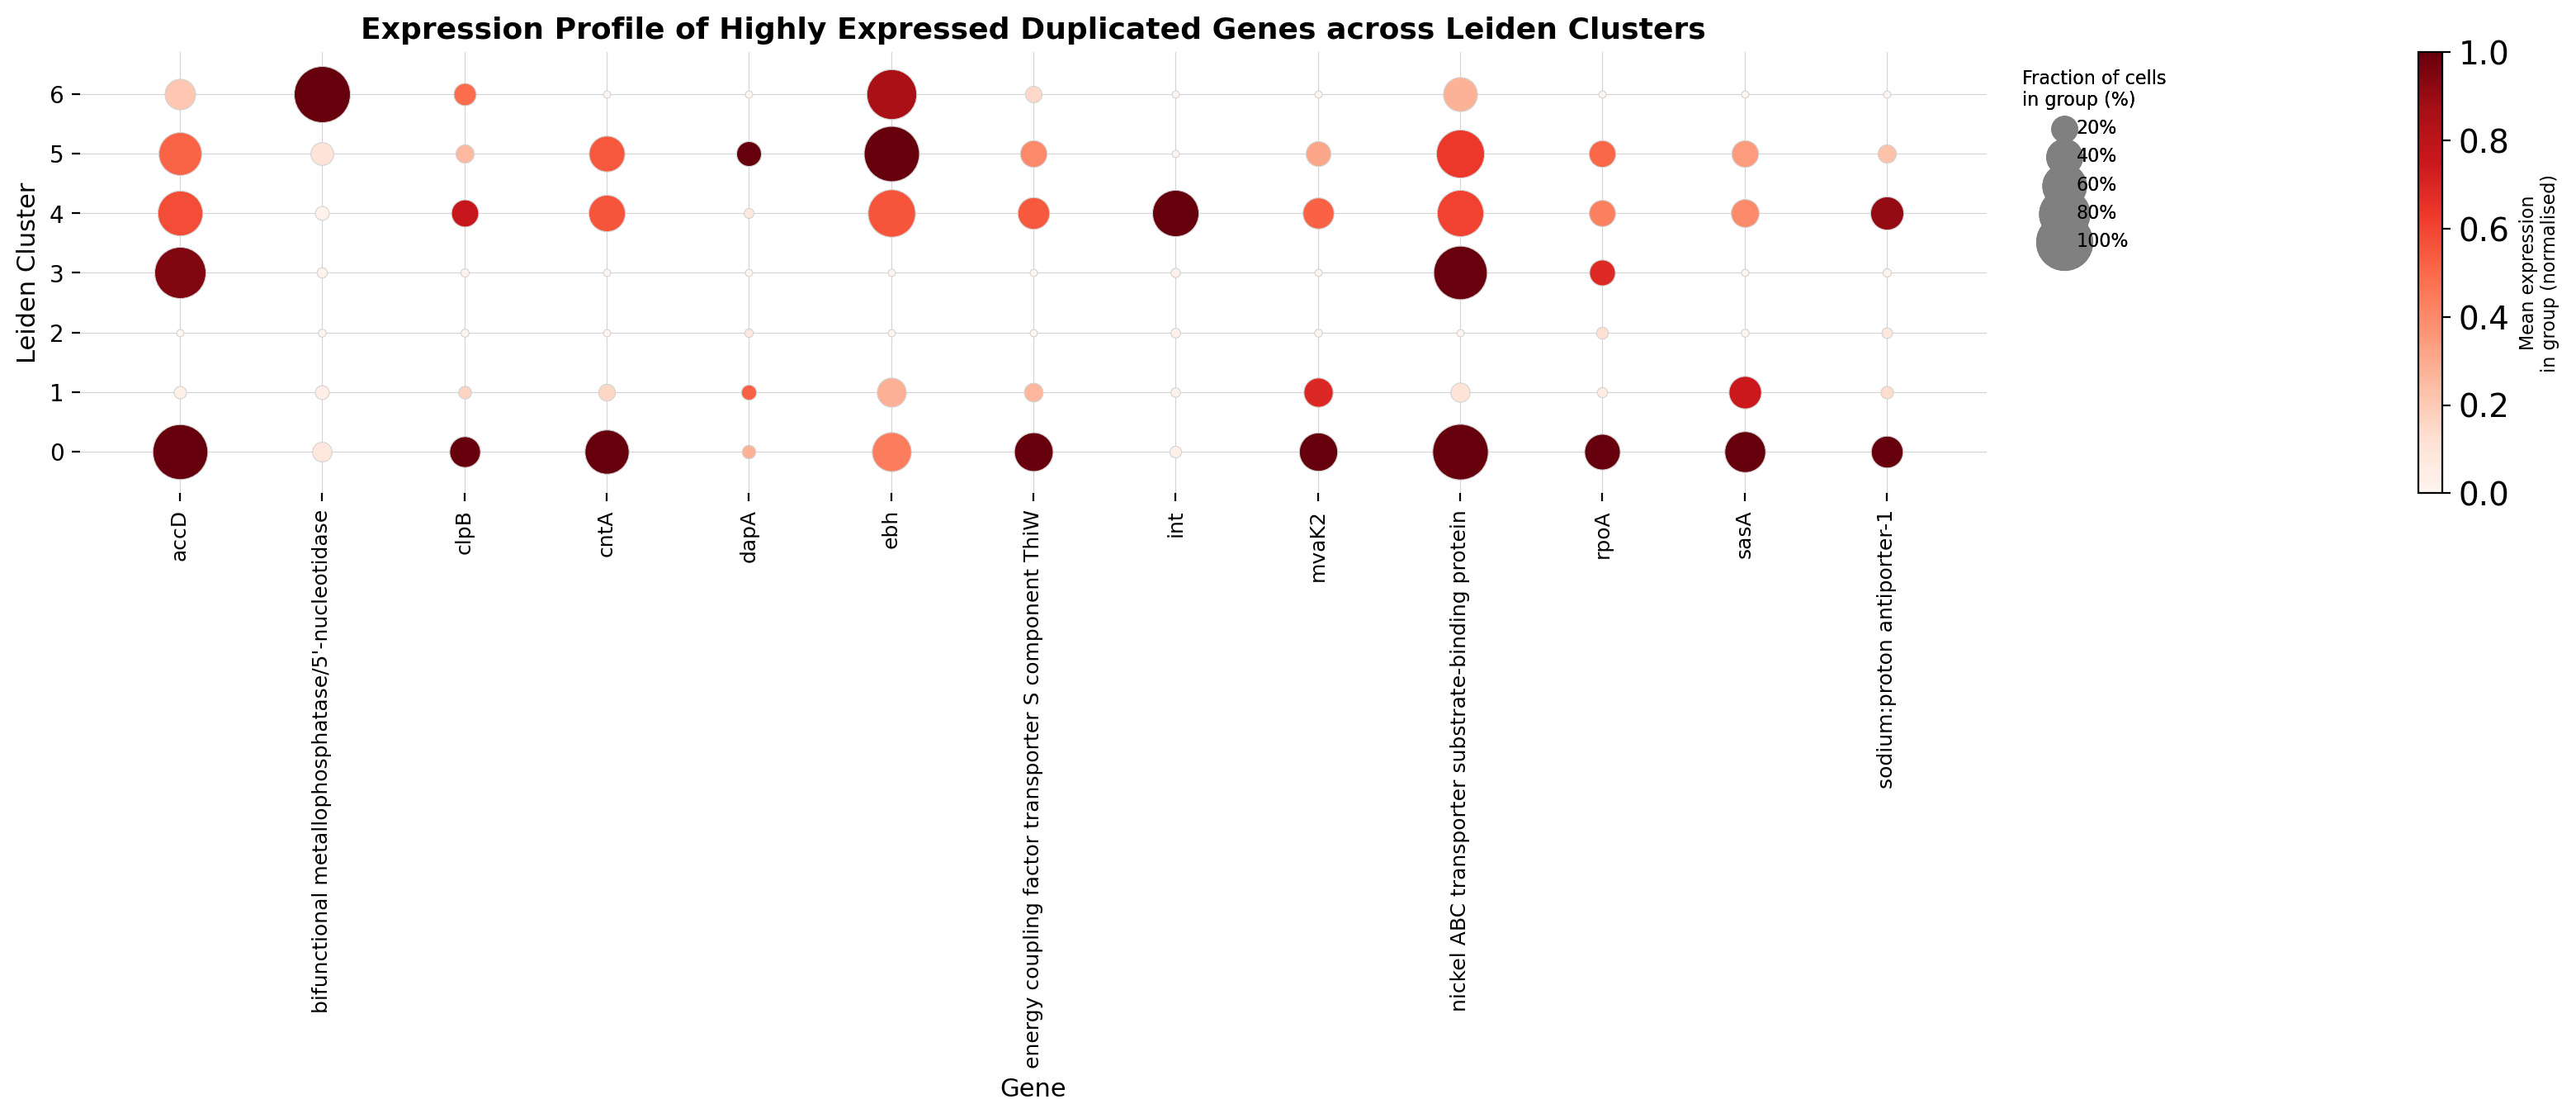

In [48]:
import anndata as ad
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.sparse as sp
import warnings
warnings.filterwarnings("ignore")

adata = ad.read_h5ad("/mnt/c/Users/natha/OneDrive/Bio-informatica_25-26/International Internship/Internship-25-26/CellTypist_pipeline/data/bacteria_leiden_coordinates.h5ad")
adata.obs_names_make_unique()

print(adata)
print(adata.obs.columns.tolist())
print(adata.obs['leiden'].value_counts())

target_genes = [
    "accD",
    "bifunctional metallophosphatase/5'-nucleotidase",
    "clpB",
    "cntA",
    "dapA",
    "ebh",
    "energy coupling factor transporter S component ThiW",
    "int",
    "mvaK2",
    "nickel ABC transporter substrate-binding protein",
    "rpoA",
    "sasA",
    "sodium:proton antiporter-1",
]

genes = [g for g in target_genes if g in adata.var_names]
print("Gevonden genen:", genes)

adata_sub = adata[:, genes].copy()

cluster_col = "leiden"
clusters = sorted(adata_sub.obs[cluster_col].unique(), key=lambda x: int(x))

mean_expr = np.zeros((len(clusters), len(genes)))
frac_expr = np.zeros((len(clusters), len(genes)))

for i, cl in enumerate(clusters):
    mask = adata_sub.obs[cluster_col] == cl
    X_cl = adata_sub[mask].X
    if sp.issparse(X_cl):
        X_cl = X_cl.toarray()
    mean_expr[i, :] = X_cl.mean(axis=0)
    frac_expr[i, :] = (X_cl > 0).mean(axis=0)

mean_df = pd.DataFrame(mean_expr, index=clusters, columns=genes)
frac_df = pd.DataFrame(frac_expr, index=clusters, columns=genes)
col_max = mean_df.max(axis=0).replace(0, 1)
mean_norm = mean_df.div(col_max, axis=1)

fig, ax = plt.subplots(figsize=(16, 7))
cmap = plt.cm.Reds
MAX_S, MIN_S = 600, 10

for gi, gene in enumerate(genes):
    for ci, cl in enumerate(clusters):
        size  = MIN_S + frac_df.loc[cl, gene] * (MAX_S - MIN_S)
        color = cmap(mean_norm.loc[cl, gene])
        ax.scatter(gi, ci, s=size, color=color, edgecolors="lightgrey", linewidths=0.4, zorder=3)

ax.set_xticks(range(len(genes)))
ax.set_xticklabels(genes, rotation=90, ha="center", fontsize=9)
ax.set_yticks(range(len(clusters)))
ax.set_yticklabels(clusters, fontsize=10)
ax.set_xlabel("Gene", fontsize=11)
ax.set_ylabel("Leiden Cluster", fontsize=11)
ax.set_title("Expression Profile of Highly Expressed Duplicated Genes across Leiden Clusters", fontsize=13, fontweight="bold")
ax.set_xlim(-0.7, len(genes) - 0.3)
ax.set_ylim(-0.7, len(clusters) - 0.3)
ax.grid(True, color="lightgrey", linewidth=0.4, zorder=0)
for spine in ax.spines.values():
    spine.set_visible(False)

legend_handles = [
    plt.scatter([], [], s=MIN_S + f*(MAX_S-MIN_S), color="grey", edgecolors="grey", linewidths=0.4, label=f"{int(f*100)}%")
    for f in [0.2, 0.4, 0.6, 0.8, 1.0]
]
leg = ax.legend(handles=legend_handles, title="Fraction of cells\nin group (%)", title_fontsize=8,
                fontsize=8, loc="upper left", bbox_to_anchor=(1.01, 1.0), frameon=False)
ax.add_artist(leg)

sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(0, 1))
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, fraction=0.025, pad=0.18, aspect=18)
cbar.set_label("Mean expression\nin group (normalised)", fontsize=8)

plt.tight_layout()
plt.savefig("/mnt/c/Users/natha/OneDrive/Bio-informatica_25-26/International Internship/Internship-25-26/CellTypist_pipeline/data/bubbleplot_highly_LEIDEN.png", dpi=180, bbox_inches="tight", facecolor="white")
plt.show()

## 📊 Expression Profiles of Duplicated Genes across MICA Clusters

--- STEP 1: VERIFYING THE INPUT COLUMNS ---
Available columns in metadata: ['total_counts', 'sample', 'projectID', 'nUMI', 'nFeature', 'pctMito', 'pctSpikeIn', 'CellID', 'clusterID', 'UMAP_1', 'UMAP_2']

First 5 rows of coordinates and clusters:
          UMAP_1    UMAP_2  clusterID
bf_68  -4.870040 -1.197901          2
bf_96   3.291710 -4.690308          1
bf_104 -3.705104 -7.530192          5
bf_107 -3.989484 -8.999247          5
bf_131  1.080232 -1.099291          4

--- STEP 2: ASSEMBLING ANNDATA OBJECT ---


... storing 'sample' as categorical
... storing 'projectID' as categorical



--- STEP 3: MAPPING MICA COORDINATES TO OBSM ---
Coordinates successfully moved to .obsm['X_umap']!
Current metadata columns remaining: ['total_counts', 'sample', 'projectID', 'nUMI', 'nFeature', 'pctMito', 'pctSpikeIn', 'CellID', 'clusterID']

--- STEP 4: GENERATING THE MICA CLUSTER PLOT ---


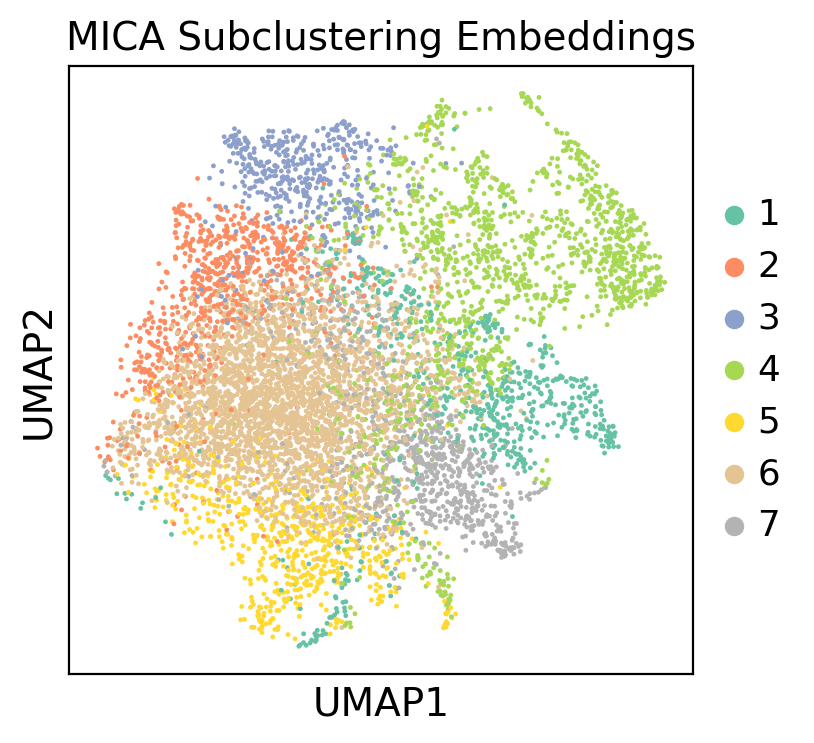


SUCCESS: Master H5AD file saved cleanly to: ./DATA/bacteria_mica_coordinates.h5ad


In [49]:
import os
import scanpy as sc
import anndata as ad
import pandas as pd

# ==============================================================================
# STEP 1: DIRECTORY CONFIGURATION & DATA LOADING
# ==============================================================================
# Direct Python to your precise project folder


print("--- STEP 1: VERIFYING THE INPUT COLUMNS ---")
# Open and inspect the raw cell annotations CSV file
metadata = pd.read_csv("./metadata_voor_python.csv", index_col=0)

# Check if UMAP_1, UMAP_2, and clusterID exist in the raw file
print("Available columns in metadata:", metadata.columns.tolist())
print("\nFirst 5 rows of coordinates and clusters:")
print(metadata[['UMAP_1', 'UMAP_2', 'clusterID']].head(5))

# ==============================================================================
# STEP 2: ANNDATA OBJECT ASSEMBLY
# ==============================================================================
print("\n--- STEP 2: ASSEMBLING ANNDATA OBJECT ---")
# Load the raw transposed expression matrix
counts = pd.read_csv("./matrix_voor_python.csv", index_col=0)

# Build the AnnData structure
adata = ad.AnnData(X=counts.values, obs=metadata)
adata.obs_names = counts.index.astype(str)
adata.var_names = counts.columns.astype(str)

# ==============================================================================
# STEP 3: RECONSTRUCT SPATIAL OBSM SLOTS FOR SCANPY
# ==============================================================================
print("\n--- STEP 3: MAPPING MICA COORDINATES TO OBSM ---")
# Extract coordinates as a 2D numpy matrix and move them into .obsm['X_umap']
adata.obsm['X_umap'] = adata.obs[['UMAP_1', 'UMAP_2']].to_numpy()

# Drop the loose spatial columns from the cell metadata table to prevent duplication
adata.obs = adata.obs.drop(columns=['UMAP_1', 'UMAP_2'])

# Cast the MICA subclustering identifiers to categorical values for discrete colors
adata.obs['clusterID'] = adata.obs['clusterID'].astype(str).astype('category')

print("Coordinates successfully moved to .obsm['X_umap']!")
print("Current metadata columns remaining:", adata.obs.columns.tolist())

# ==============================================================================
# STEP 4: VISUALIZATION & OUTPUT EXPORT
# ==============================================================================
print("\n--- STEP 4: GENERATING THE MICA CLUSTER PLOT ---")
# Because we populated .obsm['X_umap'], sc.pl.umap targets these coordinates automatically
sc.pl.umap(
    adata, 
    color='clusterID', 
    title='MICA Subclustering Embeddings',
    palette='Set2',      # Distinct qualitative palette for the 7 subclusters
    size=12,             # Adjust node sizing to maintain readability
    frameon=True
)

# Save the final consolidated object as an H5AD file
os.makedirs("./DATA", exist_ok=True)
output_h5ad = "./DATA/bacteria_mica_coordinates.h5ad"
adata.write_h5ad(output_h5ad)

print(f"\nSUCCESS: Master H5AD file saved cleanly to: {output_h5ad}")

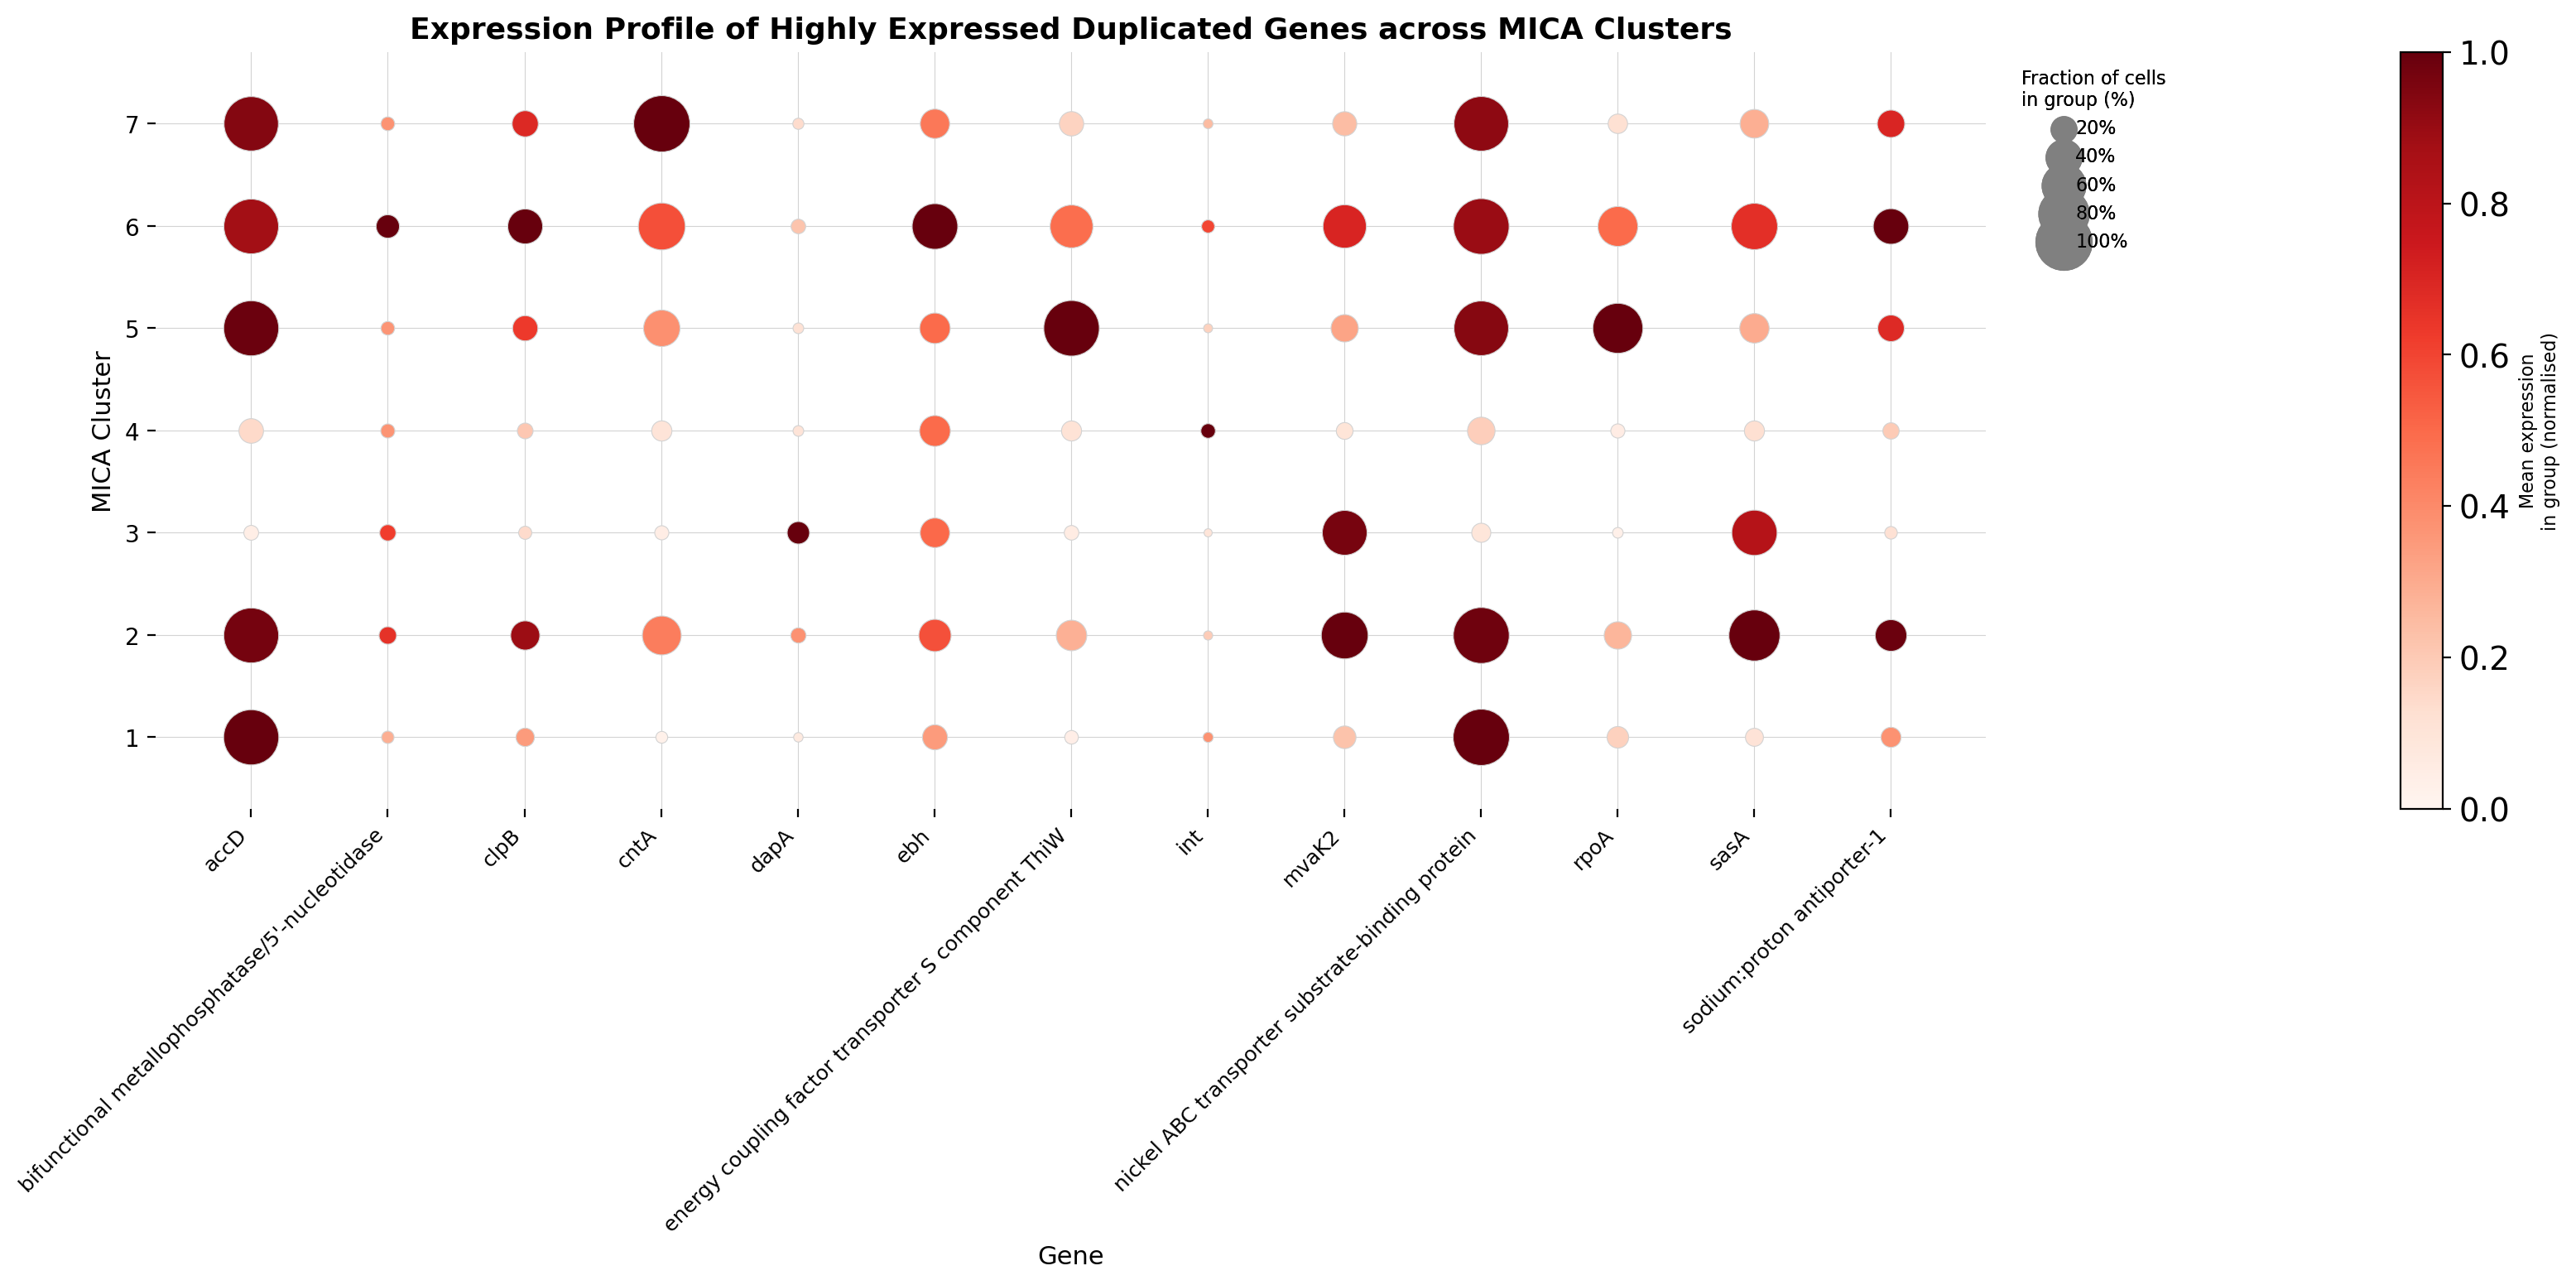

In [51]:
import anndata as ad
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.sparse as sp
import warnings
warnings.filterwarnings("ignore")

# 1. Data inladen -> VOEG HIER './DATA/' TOE
adata = ad.read_h5ad("./DATA/bacteria_mica_coordinates.h5ad")
# HARDCODED GENEN: Jouw specifieke genenlijst
target_genes = [
    "accD",
    "bifunctional metallophosphatase/5'-nucleotidase",
    "clpB",
    "cntA",
    "dapA",
    "ebh",
    "energy coupling factor transporter S component ThiW",
    "int",
    "mvaK2",
    "nickel ABC transporter substrate-binding protein",
    "rpoA",
    "sasA",
    "sodium:proton antiporter-1"
]

# Controleer welke van de hardcoded genen daadwerkelijk in de dataset zitten
genes = [g for g in target_genes if g in adata.var_names]

# Veiligheidscheck: als er 0 gennamen matchen, geeft de code een duidelijke melding
if len(genes) == 0:
    print("Beschikbare gennamen in adata (eerste 10):", list(adata.var_names[:10]))
    raise ValueError("Geen van de gehardcode genen matcht met de genen in 'adata.var_names'! Controleer de spelling.")

adata_sub = adata[:, genes].copy()

cluster_col = "clusterID"
# Sorteer clusters numeriek
clusters = sorted(adata_sub.obs[cluster_col].unique(), key=lambda x: int(x))

# 2. Matrices initialiseren
mean_expr = np.zeros((len(clusters), len(genes)))
frac_expr = np.zeros((len(clusters), len(genes)))

# 3. Berekeningen per cluster
for i, cl in enumerate(clusters):
    mask = adata_sub.obs[cluster_col] == cl
    X_cl = adata_sub[mask].X
    
    if sp.issparse(X_cl):
        X_cl = X_cl.toarray()
    
    # Voorkomt broadcasting/shape errors door het resultaat te 'squeezen' naar 1D
    mean_expr[i, :] = np.asarray(X_cl.mean(axis=0)).squeeze()
    frac_expr[i, :] = np.asarray((X_cl > 0).mean(axis=0)).squeeze()

# 4. DataFrames en normalisatie
mean_df = pd.DataFrame(mean_expr, index=clusters, columns=genes)
frac_df = pd.DataFrame(frac_expr, index=clusters, columns=genes)
col_max = mean_df.max(axis=0).replace(0, 1)
mean_norm = mean_df.div(col_max, axis=1)

# 5. Plotten (Figuurgrootte licht aangepast voor de langere gennamen)
fig, ax = plt.subplots(figsize=(16, 8))
cmap = plt.cm.Reds
MAX_S, MIN_S = 600, 10

for gi, gene in enumerate(genes):
    for ci, cl in enumerate(clusters):
        size  = MIN_S + frac_df.loc[cl, gene] * (MAX_S - MIN_S)
        color = cmap(mean_norm.loc[cl, gene])
        ax.scatter(gi, ci, s=size, color=color, edgecolors="lightgrey", linewidths=0.4, zorder=3)

# Opmaak van de assen
ax.set_xticks(range(len(genes)))
ax.set_xticklabels(genes, rotation=45, ha="right", fontsize=9)
ax.set_yticks(range(len(clusters)))
ax.set_yticklabels(clusters, fontsize=10)
ax.set_xlabel("Gene", fontsize=11)
ax.set_ylabel("MICA Cluster", fontsize=11)
ax.set_title("Expression Profile of Highly Expressed Duplicated Genes across MICA Clusters", fontsize=13, fontweight="bold")
ax.set_xlim(-0.7, len(genes) - 0.3)
ax.set_ylim(-0.7, len(clusters) - 0.3)
ax.grid(True, color="lightgrey", linewidth=0.4, zorder=0)

# Verwijder de randen (spines) voor een cleanere look
for spine in ax.spines.values():
    spine.set_visible(False)

# Legenda voor de fractie cellen (grootte van de bollen)
legend_handles = [
    plt.scatter([], [], s=MIN_S + f*(MAX_S-MIN_S), color="grey", edgecolors="grey", linewidths=0.4, label=f"{int(f*100)}%")
    for f in [0.2, 0.4, 0.6, 0.8, 1.0]
]
leg = ax.legend(handles=legend_handles, title="Fraction of cells\nin group (%)", title_fontsize=8,
                fontsize=8, loc="upper left", bbox_to_anchor=(1.01, 1.0), frameon=False)
ax.add_artist(leg)

# Colorbar voor de gemiddelde expressie (kleurintensiteit)
sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(0, 1))
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, fraction=0.025, pad=0.18, aspect=18)
cbar.set_label("Mean expression\nin group (normalised)", fontsize=8)

plt.tight_layout()
plt.savefig("bubbleplot_highly_MICA.png", dpi=180, bbox_inches="tight", facecolor="white")
plt.show()

In [53]:
print("=== MICA ===")
print(adata_mica)
print(adata_mica.obs.columns.tolist())
print(adata_mica.obs['clusterID'].value_counts())

print("\n=== LEIDEN ===")
print(adata_leiden)
print(adata_leiden.obs.columns.tolist())
print(adata_leiden.obs['leiden'].value_counts())
print(adata_leiden.obs['leiden'].value_counts().sort_index())

=== MICA ===
AnnData object with n_obs × n_vars = 7884 × 2853
    obs: 'total_counts', 'sample', 'projectID', 'nUMI', 'nFeature', 'pctMito', 'pctSpikeIn', 'CellID', 'clusterID'
    uns: 'clusterID_colors'
    obsm: 'X_umap'
['total_counts', 'sample', 'projectID', 'nUMI', 'nFeature', 'pctMito', 'pctSpikeIn', 'CellID', 'clusterID']
clusterID
6    2981
4    1427
7     872
2     792
1     681
5     660
3     471
Name: count, dtype: int64

=== LEIDEN ===
AnnData object with n_obs × n_vars = 7884 × 2853
    obs: 'total_counts', 'sample', 'leiden', 'Leiden_Cluster', 'Condition'
    uns: 'leiden', 'leiden_colors', 'neighbors', 'pca', 'sample_colors', 'umap', 'wilcoxon_leiden'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'
['total_counts', 'sample', 'leiden', 'Leiden_Cluster', 'Condition']
leiden
0    5930
1    1361
2     306
3     172
4      68
5      33
6      14
Name: count, dtype: int64
leiden
0    5930
1    1361
2     306
3     172
4      68
5      33
6

In [65]:
# Determine the correct column name for Leiden
leiden_col = 'Leiden_Cluster' if 'Leiden_Cluster' in obs_leiden_aligned.columns else 'leiden'

# 1. Count the number of unique clusters
num_mica_clusters = obs_mica_aligned['clusterID'].nunique()
num_leiden_clusters = obs_leiden_aligned[leiden_col].nunique()

print("="*60)
print("🔢 NUMBER OF CLUSTERS CHECK")
print("="*60)
print(f"MICA:   {num_mica_clusters} unique clusters")
print(f"Leiden: {num_leiden_clusters} unique clusters")
print("-"*60)

# 2. Print the exact unique labels/names present in the columns
print("\n🔮 UNIQUE LABELS IN EACH PIPELINE:")
print(f" -> MICA labels:   {sorted(obs_mica_aligned['clusterID'].unique())}")
print(f" -> Leiden labels: {sorted(obs_leiden_aligned[leiden_col].unique())}")

🔢 NUMBER OF CLUSTERS CHECK
MICA:   7 unique clusters
Leiden: 7 unique clusters
------------------------------------------------------------

🔮 UNIQUE LABELS IN EACH PIPELINE:
 -> MICA labels:   ['1', '2', '3', '4', '5', '6', '7']
 -> Leiden labels: ['0', '1', '2', '3', '4', '5', '6']


In [66]:
# 1. Make sure you use the correct column name for Leiden
leiden_col = 'Leiden_Cluster' if 'Leiden_Cluster' in obs_leiden_aligned.columns else 'leiden'

# 2. Define the exact changes you want to make (from old number to new number)
# Make sure the keys (left side) match the exact type in your dataframe (as strings)
cluster_mapping = {
    "0": "1",
    "1": "2",
    "2": "3",
    "3": "4",
    "4": "5",
    "5": "6",
    "6": "7"
}

# 3. Create a new column with the updated cluster numbers
obs_leiden_aligned['Leiden_Shifted'] = obs_leiden_aligned[leiden_col].astype(str).map(cluster_mapping)

# 4. Also update it in your original adata object so you can use it for plots later
adata_leiden.obs['Leiden_Shifted'] = adata_leiden.obs['leiden'].astype(str).map(cluster_mapping)
adata_leiden.obs['Leiden_Shifted'] = adata_leiden.obs['Leiden_Shifted'].astype('category')

# ==============================================================================
# VERIFICATION CHECKS
# ==============================================================================
print("="*60)
print("✅ VERIFICATION OF THE SHIFTED CLUSTERS")
print("="*60)
# Show a quick preview to see if 0 turned into 1, and 6 turned into 7
print(obs_leiden_aligned[[leiden_col, 'Leiden_Shifted']].head(10))

print("\n🔮 New unique labels in Leiden_Shifted:")
print(sorted(obs_leiden_aligned['Leiden_Shifted'].unique()))

✅ VERIFICATION OF THE SHIFTED CLUSTERS
    Leiden_Cluster Leiden_Shifted
68               0              1
96               0              1
104              0              1
107              0              1
131              1              2
132              1              2
186              0              1
220              0              1
290              1              2
292              0              1

🔮 New unique labels in Leiden_Shifted:
['1', '2', '3', '4', '5', '6', '7']


In [68]:
import pandas as pd
import numpy as np
from scipy.optimize import linear_sum_assignment
from sklearn.metrics import adjusted_rand_score

# ==============================================================================
# 1. ALIGN CELL BARCODES ACROSS OBJECTS (USING THE ASSIGNED COMMON CELLS)
# ==============================================================================
# We use the aligned dataframes we verified earlier to make sure rows match exactly
labels_mica = obs_mica_aligned['clusterID'].astype(str)
labels_leiden_shifted = obs_leiden_aligned['Leiden_Shifted'].astype(str)

# ==============================================================================
# 2. COMPUTE ADJUSTED RAND INDEX (ARI)
# ==============================================================================
ari_score = adjusted_rand_score(labels_mica, labels_leiden_shifted)
print(f"🎯 Adjusted Rand Index (ARI) before automated alignment: {ari_score:.4f}")

# ==============================================================================
# 3. CREATE A CONFUSION MATRIX (CONTINGENCY TABLE)
# ==============================================================================
# Using your exact active column names
contingency_matrix = pd.crosstab(labels_mica, labels_leiden_shifted)
print("\n📊 Contingency Matrix (MICA vs Shifted Leiden):")
print(contingency_matrix)

# ==============================================================================
# 4. CONVERT OVERLAPS INTO A MINIMIZATION COST MATRIX
# ==============================================================================
cost_matrix = contingency_matrix.max().max() - contingency_matrix.values

# ==============================================================================
# 5. APPLY THE HUNGARIAN ALGORITHM
# ==============================================================================
# Mathematically finds the absolute best 1-to-1 matching strategy
row_ind, col_ind = linear_sum_assignment(cost_matrix)

# ==============================================================================
# 6. BUILD THE CLUSTER MAPPING DICTIONARY
# ==============================================================================
leiden_old_labels = contingency_matrix.columns[col_ind]
mica_labels = contingency_matrix.index[row_ind]
hungarian_mapping = dict(zip(leiden_old_labels, mica_labels))

print("\n🔮 Optimal Automated Mapping Found by Hungarian Algorithm:")
for old, new in hungarian_mapping.items():
    print(f" -> Leiden Cluster '{old}' matches best with MICA Cluster '{new}'")

# ==============================================================================
# 7. GENERATE ALIGNED CLUSTER LABELS
# ==============================================================================
# Save the final perfect match columns into your dataframes and master AnnData object
obs_leiden_aligned['leiden_hungarian_aligned'] = obs_leiden_aligned['Leiden_Shifted'].astype(str).map(hungarian_mapping)
adata_leiden.obs['leiden_hungarian_aligned'] = adata_leiden.obs['Leiden_Shifted'].astype(str).map(hungarian_mapping)
adata_leiden.obs['leiden_hungarian_aligned'] = adata_leiden.obs['leiden_hungarian_aligned'].astype('category')

print("\n✅ Setup complete! Automated matching layer 'leiden_hungarian_aligned' added successfully.")

🎯 Adjusted Rand Index (ARI) before automated alignment: 0.1783

📊 Contingency Matrix (MICA vs Shifted Leiden):
Leiden_Shifted    1    2    3    4   5   6  7
clusterID                                    
1               401   12    0  128   1   0  0
2               497   20    0    0   0   0  0
3                11  408    0    0   0   0  0
4                61  623  299   27  23  14  8
5               357   23    2    5   0   0  0
6               187   74    1    1   0   1  0
7               454   30    0    0   0   0  0

🔮 Optimal Automated Mapping Found by Hungarian Algorithm:
 -> Leiden Cluster '4' matches best with MICA Cluster '1'
 -> Leiden Cluster '1' matches best with MICA Cluster '2'
 -> Leiden Cluster '2' matches best with MICA Cluster '3'
 -> Leiden Cluster '3' matches best with MICA Cluster '4'
 -> Leiden Cluster '5' matches best with MICA Cluster '5'
 -> Leiden Cluster '6' matches best with MICA Cluster '6'
 -> Leiden Cluster '7' matches best with MICA Cluster '7'

✅ Setup c

In [69]:
import scanpy as sc
import numpy as np
from sklearn.metrics import silhouette_score

# ==============================================================================
# 1. DEFINE THE 11 EXPLAINABLE MARKER GENES (FROM YOUR BUBBLE PLOTS)
# ==============================================================================
# Replacing placeholders with the actual genes present in your data
genes_of_interest = [
    'accD', 'clpB', 'cntA', 'dapA', 'ebh', 
    'int', 'mvaK2', 'rpoA', 'sasA', 'sodium:proton antiporter-1',
    'bifunctional metallophosphatase/5\'-nucleotidase'
]

# Ensure genes actually exist in your objects to prevent KeyErrors
genes_of_interest = [g for g in genes_of_interest if g in adata_leiden.var_names and g in adata_mica.var_names]
print(f"🧬 Evaluating cluster quality using {len(genes_of_interest)} verified marker genes.")

# ==============================================================================
# 2. SUBSET EXPRESSION MATRICES
# ==============================================================================
X_mica_subset = adata_mica[:, genes_of_interest].X
X_leiden_subset = adata_leiden[:, genes_of_interest].X

# ==============================================================================
# 3. CONVERT SPARSE MATRICES TO DENSE ARRAYS
# ==============================================================================
if not isinstance(X_mica_subset, np.ndarray):
    X_mica_subset = X_mica_subset.toarray()
if not isinstance(X_leiden_subset, np.ndarray):
    X_leiden_subset = X_leiden_subset.toarray()

# ==============================================================================
# 4. CALCULATE SILHOUETTE SCORES (USING YOUR CORRECT COLUMN NAMES)
# ==============================================================================
print("\n⏳ Calculating Silhouette Scores (this might take a minute)...")

# MICA uses 'clusterID'
score_mica = silhouette_score(X_mica_subset, adata_mica.obs['clusterID'].astype(str))

# Leiden uses your freshly created 'leiden_hungarian_aligned' column
score_leiden = silhouette_score(X_leiden_subset, adata_leiden.obs['leiden_hungarian_aligned'].astype(str))

# ==============================================================================
# 5. PRINT EVALUATION METRICS
# ==============================================================================
print("\n" + "="*60)
print("✨ SILHOUETTE SCORE RESULTS (SCALE: -1.0 TO 1.0)")
print("="*60)
print(f"🧬 MICA (scMINER) Silhouette Score: {score_mica:.4f}")
print(f"🧬 Leiden Silhouette Score:         {score_leiden:.4f}")
print("-"*60)

# Quick interpretation helper
if score_mica > score_leiden:
    print(f"💡 Conclusion: MICA created tighter, better-separated boundaries for these 11 genes (diff: {score_mica-score_leiden:.4f}).")
else:
    print(f"💡 Conclusion: Leiden created tighter, better-separated boundaries for these 11 genes (diff: {score_leiden-score_mica:.4f}).")

🧬 Evaluating cluster quality using 11 verified marker genes.

⏳ Calculating Silhouette Scores (this might take a minute)...

✨ SILHOUETTE SCORE RESULTS (SCALE: -1.0 TO 1.0)
🧬 MICA (scMINER) Silhouette Score: 0.0471
🧬 Leiden Silhouette Score:         -0.1064
------------------------------------------------------------
💡 Conclusion: MICA created tighter, better-separated boundaries for these 11 genes (diff: 0.1535).


# this is to try some code


In [ ]:


# 1. Run the differential expression analysis (remains the same)
sc.tl.rank_genes_groups(
    adata_bacteria, 
    groupby='leiden', 
    method='wilcoxon', 
    key_added='wilcoxon_leiden',
    pts=True  
)

# 2. Extract the top 10 marker genes per cluster
top_n_genes = 10
clusters = adata_bacteria.obs['leiden'].cat.categories
marker_dict = {}

for cluster in clusters:
    # SOLUTION: We remove pval_cutoff and log2fc_min / set them to None
    # This ensures Scanpy ALWAYS returns the top genes, even if they are less significant.
    df_cluster = sc.get.rank_genes_groups_df(
        adata_bacteria, 
        group=cluster, 
        key='wilcoxon_leiden',
        pval_cutoff=None,    # No hard p-value threshold
        log2fc_min=None      # No hard log2fc threshold
    )
    
    # OPTIONAL: Relax or turn off the 'pts' filter if clusters remain empty.
    # If you want to keep this, set it lower (e.g., > 0.01 which means 1%)
    if 'pts' in df_cluster.columns:
        df_cluster = df_cluster[df_cluster['pts'] > 0.01] 
    
    # Grab the absolute top 20 genes that remain
    filtered_genes = df_cluster['names'][:top_n_genes].tolist()
    
    # In case a cluster is truly empty (fewer than 20 genes total),
    # we pad it with a placeholder instead of causing a crash or returning NaN
    if len(filtered_genes) < top_n_genes:
        padding = [f"No marker {i}"] * (top_n_genes - len(filtered_genes))
        filtered_genes.extend(padding)

    marker_dict[f"Cluster {cluster}"] = filtered_genes

# Format into a clean table structure
top_markers_df = pd.DataFrame(dict([(k, pd.Series(v)) for k, v in marker_dict.items()]))
print("\n--- TOP 10 HIGHLY EXPRESSED GENES PER CLUSTER ---")
print(top_markers_df.to_string(index=False))

# Consolidate all unique genes
all_unique_markers = []
for genes in marker_dict.values():
    all_unique_markers.extend(genes)
all_unique_markers = list(dict.fromkeys(all_unique_markers))
print(f"\nTotal unique marker genes found for visualization: {len(all_unique_markers)}")

In [ ]:
import matplotlib.pyplot as plt
import scanpy as sc

print("--- Generating Presentation-Ready Bubbleplot ---")

ax = sc.pl.dotplot(
    adata_bacteria, 
    var_names=all_unique_markers, 
    groupby='leiden', 
    title='Expression Profile of Highly Expressed Genes across Clusters',
    expression_cutoff=0.0,
    mean_only_expressed=False,
    standard_scale='var',        # normaliseert per gen → kleuren zichtbaar ook bij lage expressie
    color_map='Reds',
    colorbar_title='Mean expression\nin group',
    size_title='Fraction of cells\nin group (%)',
    figsize=(max(20, len(all_unique_markers) * 0.4), 5),  # breedte schaalt mee met aantal genen
    show=False 
)

plt.xticks(rotation=90, fontsize=8, ha='center')
plt.tight_layout()

plt.savefig(
    "/mnt/c/Users/natha/OneDrive/Bio-informatica_25-26/International Internship/Internship-25-26/CellTypist_pipeline/PLOT/Bubbleplot_Highly_Expressed_Genes.pdf", 
    bbox_inches='tight'
)
plt.show()

print("SUCCESS: Bubbleplot exported cleanly!")

In [ ]:
import matplotlib.pyplot as plt
import scanpy as sc

print("--- Generating Presentation-Ready Bubbleplot for Duplicated Genes (Leiden Clusters) ---")

# De exacte lijst met 13 gedupliceerde genen uit jouw bestand
duplicated_genes_leiden = [
"nickel ABC transporter substrate-binding protein",
"accD",
"sasA",
"mvaK2",
"sodium:proton antiporter-1",
"clpB",
"dapA",
"int",
"rpoA",
"ebh",
"cntA"
]

# TIP: Als Scanpy klaagt over het 'bifunctional' gen vanwege de speciale tekens (/ of '),
# kun je de regel hierboven veranderen naar hoe het in jouw adata.var_names staat.

# Genereren van de dotplot/bubbleplot
ax = sc.pl.dotplot(
    adata_bacteria, 
    var_names=duplicated_genes_leiden,       # Jouw lijst met gedupliceerde genen
    groupby='leiden',                        # Groeperen op Leiden clusters
    title='Expression Profile of Overlapping Duplicated Genes across Leiden Clusters',
    expression_cutoff=0.0,
    mean_only_expressed=False,
    standard_scale='var',                    # Normaliseert per gen voor optimale kleurweergave
    color_map='Reds',
    colorbar_title='Mean expression\nin group',
    size_title='Fraction of cells\nin group (%)',
    figsize=(max(10, len(duplicated_genes_leiden) * 0.7), 5), # Iets meer ruimte per gen voor de leesbaarheid
    show=False 
)

# Layout instellingen voor de X-as labels
plt.xticks(rotation=90, fontsize=9, ha='center')
plt.tight_layout()

# Opslaan op de OneDrive locatie
output_path = "/mnt/c/Users/natha/OneDrive/Bio-informatica_25-26/International Internship/Internship-25-26/CellTypist_pipeline/PLOT/Bubbleplot_highly_expressed_Genes_mica.pdf"

plt.savefig(
    output_path, 
    bbox_inches='tight'
)
plt.show()

print(f"SUCCESS: Duplicated genes bubbleplot exported cleanly to: {output_path}")

In [ ]:
pwd()

In [ ]:
adata_bacteria.write_h5ad("./DATA/bacteria_adata_leiden.h5ad")